Import libraries and load dataset

In [144]:
# Import important libraries
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [146]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


Phase 2:

STEP 1: Check Column Names Properly

In [147]:
#  Show column names
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

STEP 2: Check Missing Values

In [148]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


Step 3: Fill the missing values

In [149]:
# Fill numerical columns with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill categorical columns with mode
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

# Check again
df.isnull().sum()

/tmp/ipykernel_15595/2700022825.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


STEP 4: Check Duplicate Data

In [150]:
df.duplicated().sum()

np.int64(0)

STEP 5: Check Unique Values

In [151]:
# Check categorical values
for col in df.select_dtypes(include='object'):
    print(col, df[col].unique())

Parental_Involvement ['Low' 'Medium' 'High']
Access_to_Resources ['High' 'Medium' 'Low']
Extracurricular_Activities ['No' 'Yes']
Motivation_Level ['Low' 'Medium' 'High']
Internet_Access ['Yes' 'No']
Family_Income ['Low' 'Medium' 'High']
Teacher_Quality ['Medium' 'High' 'Low']
School_Type ['Public' 'Private']
Peer_Influence ['Positive' 'Negative' 'Neutral']
Learning_Disabilities ['No' 'Yes']
Parental_Education_Level ['High School' 'College' 'Postgraduate']
Distance_from_Home ['Near' 'Moderate' 'Far']
Gender ['Male' 'Female']


In [152]:
df = pd.get_dummies(df, drop_first=True)

STEP 6: Save Clean Dataset

In [153]:
# Save cleaned data
df.to_csv('cleaned_student_data.csv', index=False)

In [154]:
from google.colab import files
files.download("cleaned_student_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Phase 3 : EDA (Exploratory Data Analysis)

STEP 1: Import Visualization Libraries

In [155]:
# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Better visuals
sns.set(style="whitegrid")
# Better styling
plt.style.use('ggplot')

STEP 2: Distribution of Marks

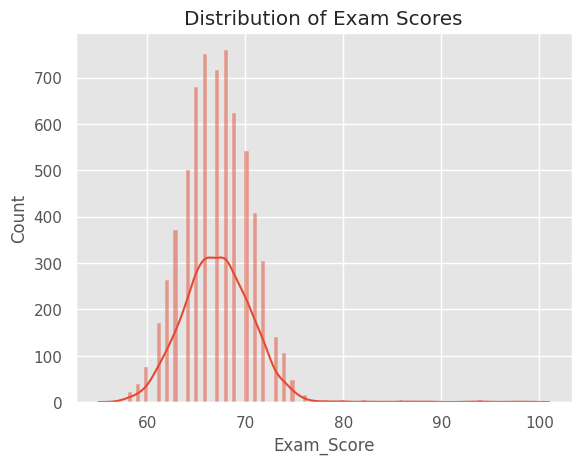

In [156]:
plt.figure()
sns.histplot(df['Exam_Score'], kde=True)
plt.title("Distribution of Exam Scores")
plt.show()

STEP 3: Study Hours vs Exam Score

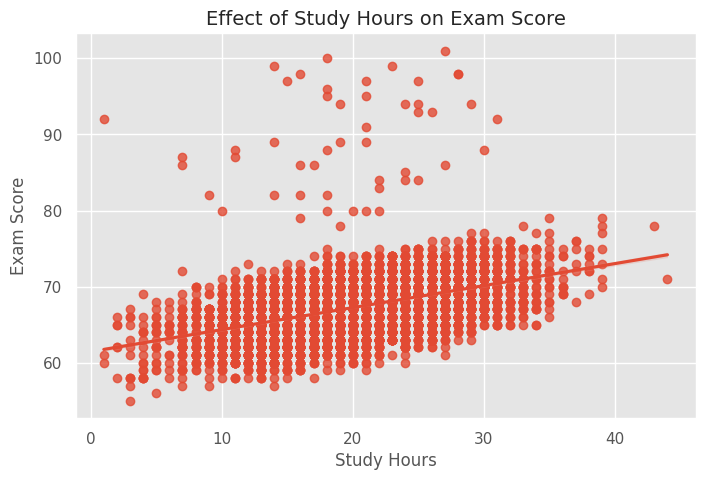

In [157]:
plt.figure(figsize=(8,5))
sns.regplot(x='Hours_Studied', y='Exam_Score', data=df)

plt.title("Effect of Study Hours on Exam Score", fontsize=14)
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")

plt.show()

STEP 4: Attendance vs Exam Score

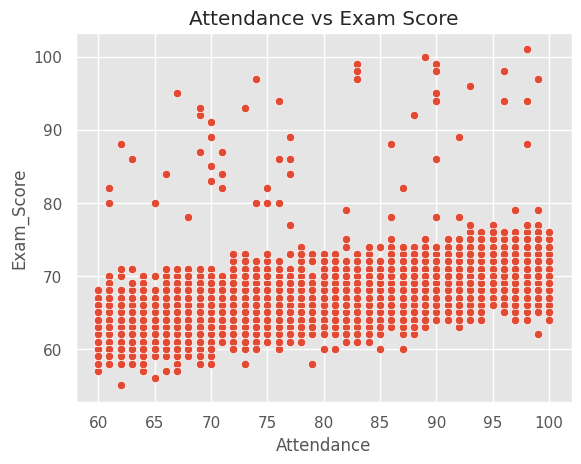

In [158]:
plt.figure()
sns.scatterplot(x='Attendance', y='Exam_Score', data=df)
plt.title("Attendance vs Exam Score")
plt.show()

correlation matrics

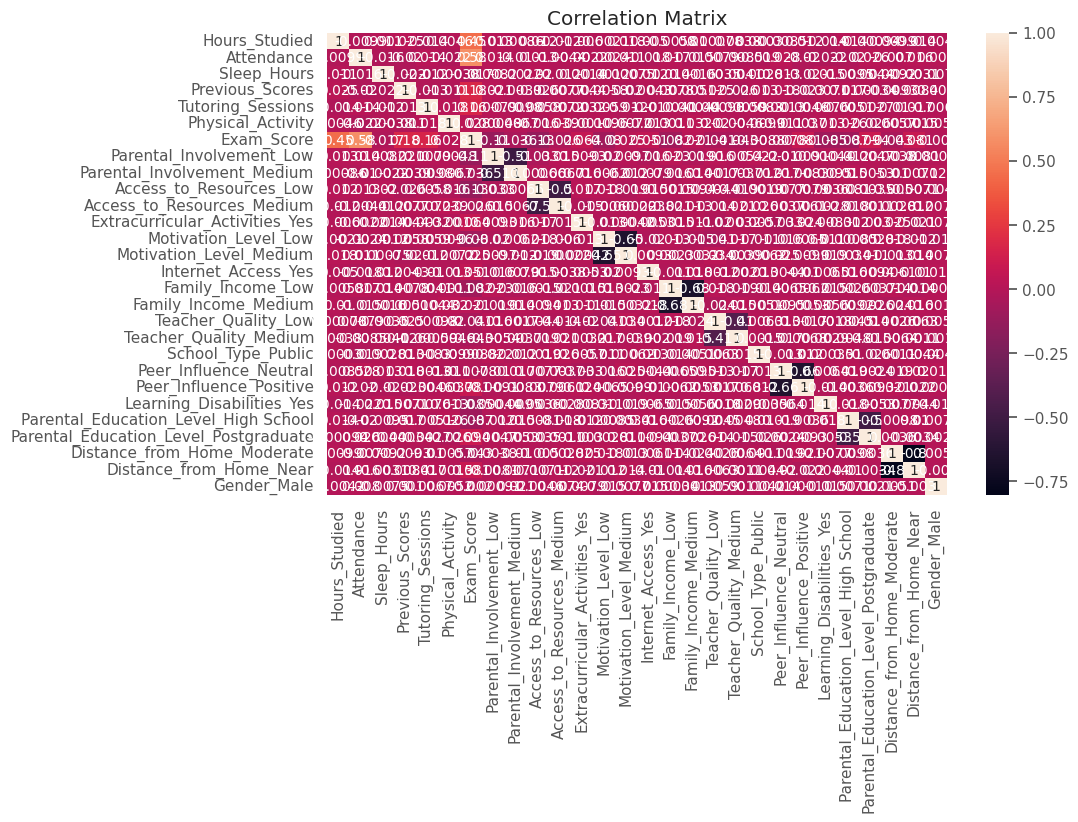

In [171]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

STEP 6: Boxplot (Outliers Detection)

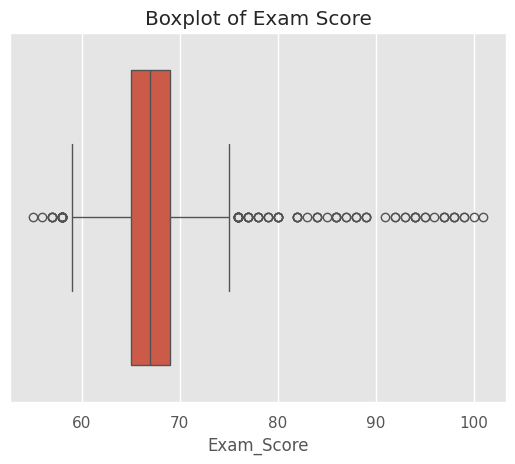

In [159]:
plt.figure()
sns.boxplot(x=df['Exam_Score'])
plt.title("Boxplot of Exam Score")
plt.show()

STEP 7: Categorical Analysis

In [172]:
for col in df.select_dtypes(include='object'):
    plt.figure()
    sns.countplot(x=col, data=df)
    plt.title(f"Count of {col}")
    plt.xticks(rotation=45)
    plt.show()

STEP 6: Save Graphs

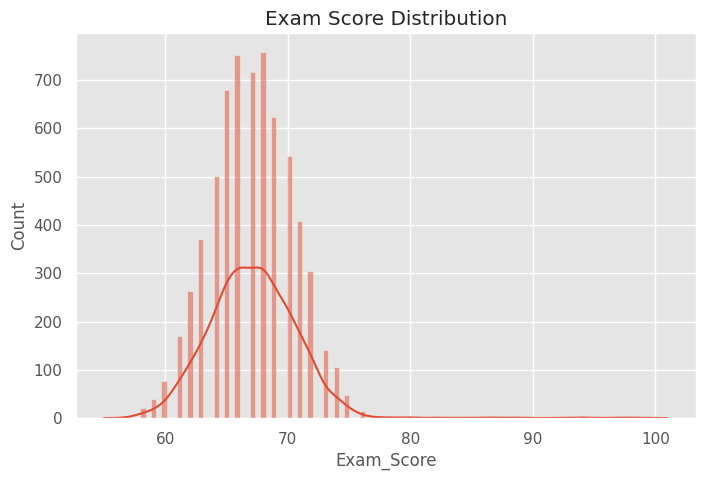

In [161]:
plt.figure(figsize=(8,5))
sns.histplot(df['Exam_Score'], kde=True)

plt.title("Exam Score Distribution")

plt.savefig("exam_score_distribution.png")
plt.show()

PHASE 6: Prediction Model

STEP 1: Import ML Libraries

In [162]:
# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

Step 2: select features

In [163]:
# Features (input)
X = df.drop('Exam_Score', axis=1)

# Target (output)
y = df['Exam_Score']

In [164]:
#  Convert categorical to numeric
X = pd.get_dummies(X, drop_first=True)

STEP 4: Train-Test Split

In [165]:
# 📌 Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

STEP 4: Train Model

In [166]:
# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

LinearRegression()

In [167]:
# Predict
y_pred = model.predict(X_test)

STEP 5: Evaluate Model

In [168]:
# 📌 Accuracy check
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.45239200896259657
R2 Score: 0.7696495724907312


In [169]:
# Compare values Actual vs Predicted
result = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
result.head()

,Actual,Predicted
743,65,64.526283
5551,65,65.265114
3442,71,71.531263
6571,64,64.277481
4204,66,66.521653


STEP 6: Plot Prediction Graph

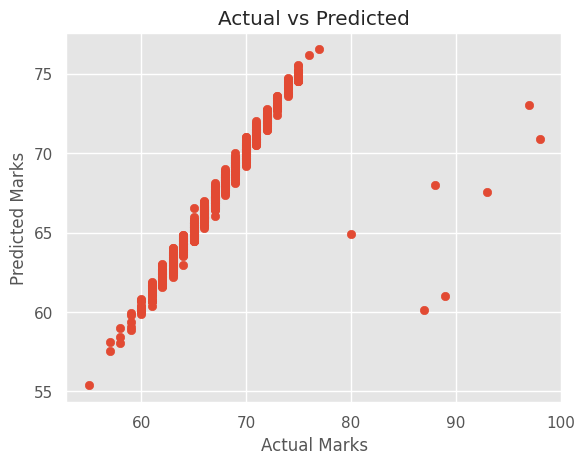

In [170]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted")
plt.show()